# Classical vs Quantum Kernels — Iris Classification Benchmark

**Ticket context:** compare classical kernel methods (scikit-learn) with MerLin's `FidelityKernel` (photonic quantum kernel) on a real classification task, verify the `FidelityKernel` documentation/API, and report time & performance comparisons.

## Short overview
- **Classical kernels** (linear, polynomial, RBF, sigmoid) implicitly map data into a (possibly infinite-dimensional) feature space and compute inner products directly with a closed-form formula.
- **Quantum fidelity kernels** (`merlin.algorithms.kernels.FidelityKernel`) encode classical data into a photonic quantum state via a parameterized circuit (`FeatureMap`) and estimate $K(x_i, x_j) = |\langle \psi(x_j) | \psi(x_i) \rangle|^2$ by simulating photon-number statistics (SLOS) instead of using a closed-form kernel.

## When to use a quantum kernel
- You want to explore feature spaces that are hard to reproduce classically (highly entangled, non-linear encodings).
- You're benchmarking whether a photonic feature map gives measurable separation/expressivity advantages on a given dataset.
- You're prototyping hybrid quantum-classical ML pipelines with photonic hardware/simulators (Perceval / MerLin).
- **Not** when you need production speed: exact simulation of the quantum kernel is far slower than classical kernels for anything beyond small/medium datasets and feature counts.

## What this notebook does
1. Loads and preprocesses the **Iris** dataset.
2. Benchmarks classical SVM kernels (linear / poly / RBF / sigmoid) — accuracy + timing.
3. Builds photonic feature maps for Iris (simple encoding, and a **data-reuploading** variant) with `FidelityKernel` — accuracy + timing, using the `CircuitBuilder` + `FeatureMap` + `FidelityKernel` construction (the non-deprecated, recommended API).
4. Summarizes results in tables/plots and documents caveats for the MerLin documentation.


In [11]:
# If needed, uncomment to install the required packages
# %pip install -q merlinquantum perceval-quandela scikit-learn pandas matplotlib torch

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

import perceval as pcvl
import merlin
from merlin.algorithms.kernels import FidelityKernel

warnings.filterwarnings("ignore", category=UserWarning)

print("torch:", torch.__version__)
print("merlin:", getattr(merlin, "__version__", "unknown"))
print("perceval:", getattr(pcvl, "__version__", "unknown"))

RNG_SEED = 42
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

torch: 2.12.1+cpu
merlin: 0.4.1
perceval: 1.2.4


## 1. Dataset — Iris

We use the classic 3-class Iris dataset (4 features: sepal length/width, petal length/width). Features are scaled to `[0, pi]` since photonic angle-encoding gates use the raw feature value as a phase; keeping inputs in a bounded, physically meaningful range is standard practice for quantum kernels (this also mirrors the *bandwidth* scaling explored elsewhere in this repository's `runner.py`/`metrics.py`).

In [12]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RNG_SEED, stratify=y
)

# Scale to [0, pi]: a natural range for angle-encoding gates (phase shifters)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

n_features = X_train.shape[1]
print(f"Train: {X_train.shape}, Test: {X_test.shape}, classes: {class_names}")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

Train: (105, 4), Test: (45, 4), classes: ['setosa' 'versicolor' 'virginica']


## 2. Classical kernels (scikit-learn)

We benchmark the standard SVM kernels available in scikit-learn: `linear`, `poly`, `rbf`, and `sigmoid`. For each kernel we measure fit time, prediction time, accuracy, and macro F1-score.

In [13]:
def benchmark_classical_kernel(kernel_name, X_train, y_train, X_test, y_test, **kwargs):
    svc = SVC(kernel=kernel_name, **kwargs)

    t0 = time.perf_counter()
    svc.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = svc.predict(X_test)
    predict_time = time.perf_counter() - t0

    return {
        "method": f"classical_{kernel_name}",
        "fit_time_s": fit_time,
        "predict_time_s": predict_time,
        "total_time_s": fit_time + predict_time,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
    }


classical_kernels = ["linear", "poly", "rbf", "sigmoid"]
classical_results = [
    benchmark_classical_kernel(k, X_train, y_train, X_test, y_test)
    for k in classical_kernels
]

pd.DataFrame(classical_results)

,method,fit_time_s,predict_time_s,total_time_s,accuracy,f1_macro
0,classical_linear,0.002032,0.000426,0.002459,0.933333,0.933259
1,classical_poly,0.001828,0.000429,0.002257,0.911111,0.909502
2,classical_rbf,0.001114,0.000244,0.001358,0.933333,0.933259
3,classical_sigmoid,0.000974,0.000243,0.001217,0.244444,0.201686


## 3. Quantum kernels on Iris

We build two photonic feature maps for the 4 Iris features (`n_modes = n_features + 1 = 5`), using `CircuitBuilder` + `FeatureMap` + `FidelityKernel` directly :
- **Simple**: `entangling layer -> angle encoding -> entangling layer`.
- **Data reuploading**: the angle encoding block is repeated twice, interleaved with entangling layers, so the classical data is "re-uploaded" deeper into the circuit — a common technique to increase the expressivity of quantum feature maps.

### Important parameters / API behavior
- `feature_map`: `FeatureMap` describing the encoding circuit; must expose exactly one `input_parameters` prefix.
- `input_state`: Fock occupation list. If omitted, defaults to alternating `[1, 0, 1, 0, ...]`; can also be derived from `n_photons`.
- `computation_space`: `"fock" | "unbunched" | "dual_rail"` (default `FOCK`). Non-FOCK spaces reject bunched/all-photon input states and detectors.
- `shots` / `sampling_method`: if `shots` is set, the exact probabilities are pseudo-sampled (`"multinomial"`, `"binomial"`, `"gaussian"`); default `shots=None` returns exact SLOS probabilities.
- `force_psd=True` (default): projects the *training* Gram matrix to the nearest positive semi-definite matrix — required by `SVC(kernel="precomputed")`.
- Calling `kernel(X)` (one dataset) → training Gram matrix. Calling `kernel(X_test, X_train)` (two datasets) → cross/test kernel matrix. Calling with two **datapoints** returns a scalar.

### Limitations / caveats
- **Not thread-safe**: the internal `CircuitConverter` holds shared mutable state — always use `num_workers=0` if wrapped in a `DataLoader`.
- Exact evaluation (no `shots`) simulates SLOS probabilities; cost grows quickly with the number of modes/photons, so it does not scale like a classical closed-form kernel.
- `input_state` length must equal the circuit's mode count (`feature_map.circuit.m`), and non-FOCK spaces impose extra photon-count restrictions.
- Only a **single** `input_parameters` prefix is supported per `FeatureMap`; repeating `add_angle_encoding(name=...)` for data reuploading claims new logical feature indices rather than reusing the original ones, so the raw input must be tiled accordingly (see `tile_for_reupload` below).
- Passing a raw `torch.Tensor` as `input_state` was removed; use Fock occupation lists (e.g. `[1, 0, 1]`).

### Related documentation
- [merlin.algorithms.kernels API reference](https://merlinquantum.ai/0.4/api_reference/api/merlin.algorithms.kernels.html)
- [MerLin quickstart — CircuitBuilder walkthrough](https://merlinquantum.ai/quickstart/first_quantum_layer.html#circuitbuilder-walkthrough)

In [14]:
def build_feature_map(n_features, n_reuploads=1, model="mzi"):
    """Build a CircuitBuilder-based FeatureMap with `n_reuploads` angle-encoding blocks.

    Each call to `add_angle_encoding(name="phi")` claims a *new* block of logical
    feature indices (0..n_features-1, then n_features..2*n_features-1, ...), so the
    feature map's input_size grows with n_reuploads. The same raw features are then
    tiled `n_reuploads` times before being fed to the kernel (see `tile_for_reupload`),
    which is what makes this genuine data reuploading rather than distinct features.
    """
    n_modes = n_features + 1
    builder = merlin.CircuitBuilder(n_modes=n_modes)
    for layer in range(n_reuploads):
        builder.add_entangling_layer(trainable=True, model=model, name=f"ent{layer}")
        builder.add_angle_encoding(modes=range(n_features), name="phi")
    builder.add_entangling_layer(trainable=True, model=model, name=f"ent{n_reuploads}")

    feature_map = merlin.FeatureMap(
        builder=builder, input_size=n_features * n_reuploads, input_parameters="phi"
    )
    return feature_map, n_modes


def make_fidelity_kernel(feature_map, n_modes):
    input_state = [1 - (i % 2) for i in range(n_modes)]  # alternating [1,0,1,0,...]
    return FidelityKernel(
        feature_map=feature_map,
        input_state=input_state,
        computation_space=merlin.ComputationSpace.FOCK,
    )


def tile_for_reupload(X_t, n_features, input_size):
    """Repeat each raw feature vector so it matches a feature map's (larger) input_size."""
    n_reuploads = input_size // n_features
    return X_t.repeat(1, n_reuploads)


def benchmark_quantum_kernel(method_name, feature_map, n_modes):
    kernel = make_fidelity_kernel(feature_map, n_modes)
    X_train_input = tile_for_reupload(X_train_t, n_features, feature_map.input_size)
    X_test_input = tile_for_reupload(X_test_t, n_features, feature_map.input_size)

    t0 = time.perf_counter()
    K_train = kernel(X_train_input)
    K_train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    K_test = kernel(X_test_input, X_train_input)
    K_test_time = time.perf_counter() - t0

    K_train_np = K_train.detach().numpy()
    K_test_np = K_test.detach().numpy()

    svc = SVC(kernel="precomputed")
    t0 = time.perf_counter()
    svc.fit(K_train_np, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = svc.predict(K_test_np)
    predict_time = time.perf_counter() - t0

    return (
        {
            "method": method_name,
            "kernel_build_time_s": K_train_time + K_test_time,
            "fit_time_s": fit_time,
            "predict_time_s": predict_time,
            "total_time_s": K_train_time + K_test_time + fit_time + predict_time,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
        },
        K_train_np,
        K_test_np,
    )

In [15]:
feature_map_simple, n_modes = build_feature_map(n_features, n_reuploads=1)
result_simple, K_train_simple, K_test_simple = benchmark_quantum_kernel(
    "quantum_fidelity_simple", feature_map_simple, n_modes
)
result_simple

{'method': 'quantum_fidelity_simple',
 'kernel_build_time_s': 1.0675588001031429,
 'fit_time_s': 0.001312800101004541,
 'predict_time_s': 0.0002383999526500702,
 'total_time_s': 1.0691100001567975,
 'accuracy': 0.9555555555555556,
 'f1_macro': 0.9555555555555556}

In [16]:
feature_map_reupload, _ = build_feature_map(n_features, n_reuploads=2)
result_reupload, K_train_reupload, K_test_reupload = benchmark_quantum_kernel(
    "quantum_fidelity_reuploading", feature_map_reupload, n_modes
)
result_reupload

{'method': 'quantum_fidelity_reuploading',
 'kernel_build_time_s': 1.722265800111927,
 'fit_time_s': 0.001660900074057281,
 'predict_time_s': 0.0003370000049471855,
 'total_time_s': 1.7242637001909316,
 'accuracy': 0.9333333333333333,
 'f1_macro': 0.9332591768631814}

Simple feature map circuit:


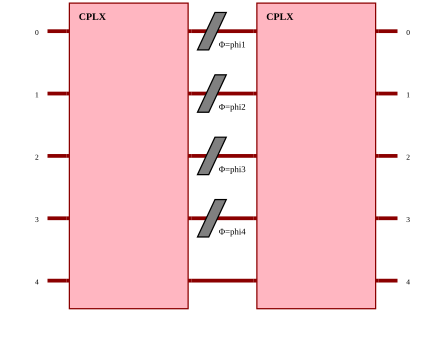

In [25]:
print("Simple feature map circuit:")
pcvl.pdisplay(feature_map_simple.circuit)

Reuploading feature map circuit:


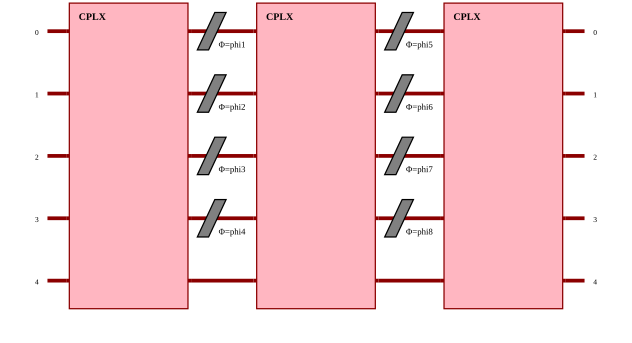

In [24]:
print("Reuploading feature map circuit:")
pcvl.pdisplay(feature_map_reupload.circuit)

## 4. Results — time & performance comparison

In [26]:
all_results = classical_results + [result_simple, result_reupload]
results_df = pd.DataFrame(all_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
results_df

,method,fit_time_s,predict_time_s,total_time_s,accuracy,f1_macro,kernel_build_time_s
0,quantum_fidelity_simple,0.001313,0.000238,1.069110,0.955556,0.955556,1.067559
1,classical_linear,0.002032,0.000426,0.002459,0.933333,0.933259,NaN
2,quantum_fidelity_reuploading,0.001661,0.000337,1.724264,0.933333,0.933259,1.722266
3,classical_rbf,0.001114,0.000244,0.001358,0.933333,0.933259,NaN
4,classical_poly,0.001828,0.000429,0.002257,0.911111,0.909502,NaN
5,classical_sigmoid,0.000974,0.000243,0.001217,0.244444,0.201686,NaN


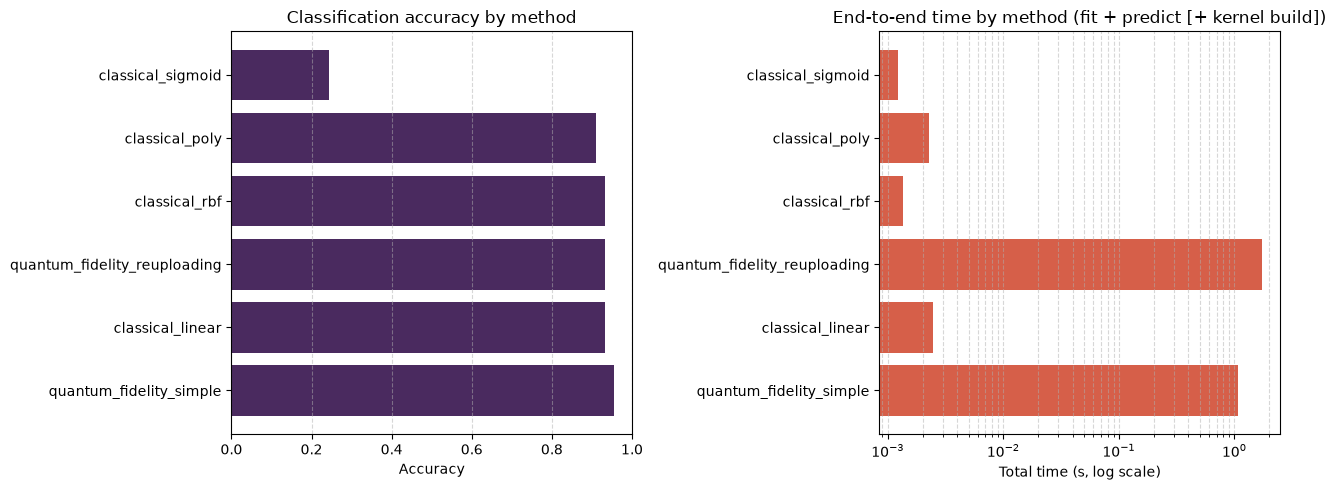

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(results_df["method"], results_df["accuracy"], color="#4a2a5f")
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Classification accuracy by method")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", ls="--", alpha=0.5)

axes[1].barh(results_df["method"], results_df["total_time_s"], color="#d65f49")
axes[1].set_xlabel("Total time (s, log scale)")
axes[1].set_xscale("log")
axes[1].set_title("End-to-end time by method (fit + predict [+ kernel build])")
axes[1].grid(axis="x", which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

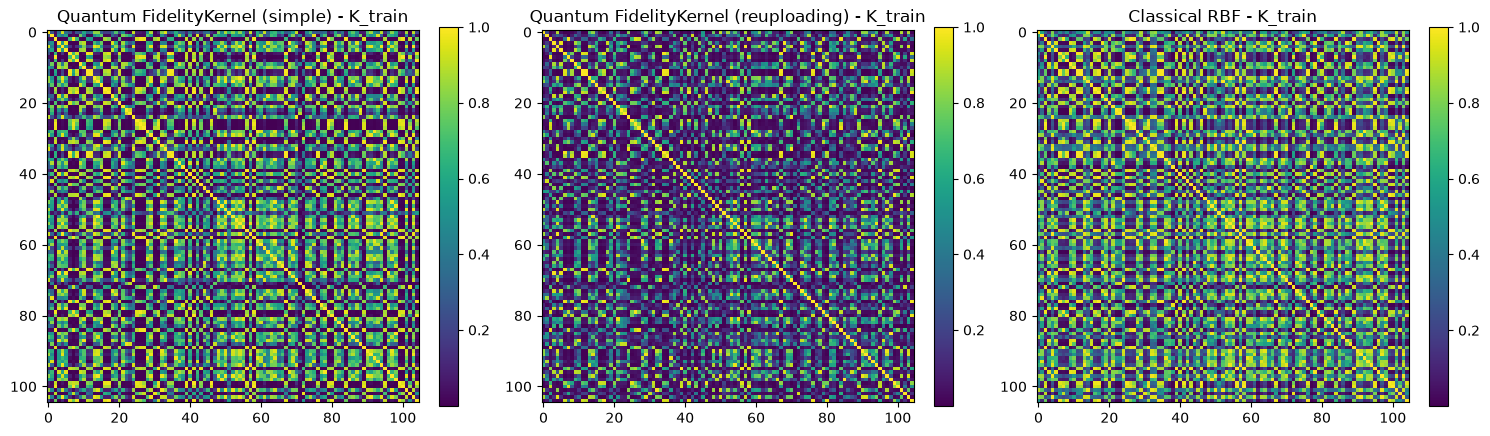

In [19]:
from sklearn.metrics.pairwise import rbf_kernel

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(K_train_simple, cmap="viridis")
axes[0].set_title("Quantum FidelityKernel (simple) - K_train")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(K_train_reupload, cmap="viridis")
axes[1].set_title("Quantum FidelityKernel (reuploading) - K_train")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

K_train_rbf = rbf_kernel(X_train)
im2 = axes[2].imshow(K_train_rbf, cmap="viridis")
axes[2].set_title("Classical RBF - K_train")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## Decision boundaries (2D PCA projection)

To visualize how classical and quantum kernels separate the three Iris classes, we project the (already `[0, pi]`-scaled) features to 2D via PCA fitted on the training set, then refit each model directly on this 2D projection purely for visualization (separate from the main benchmark above, which uses all 4 features). Decision boundaries are obtained by classifying a dense grid of points in PCA space.

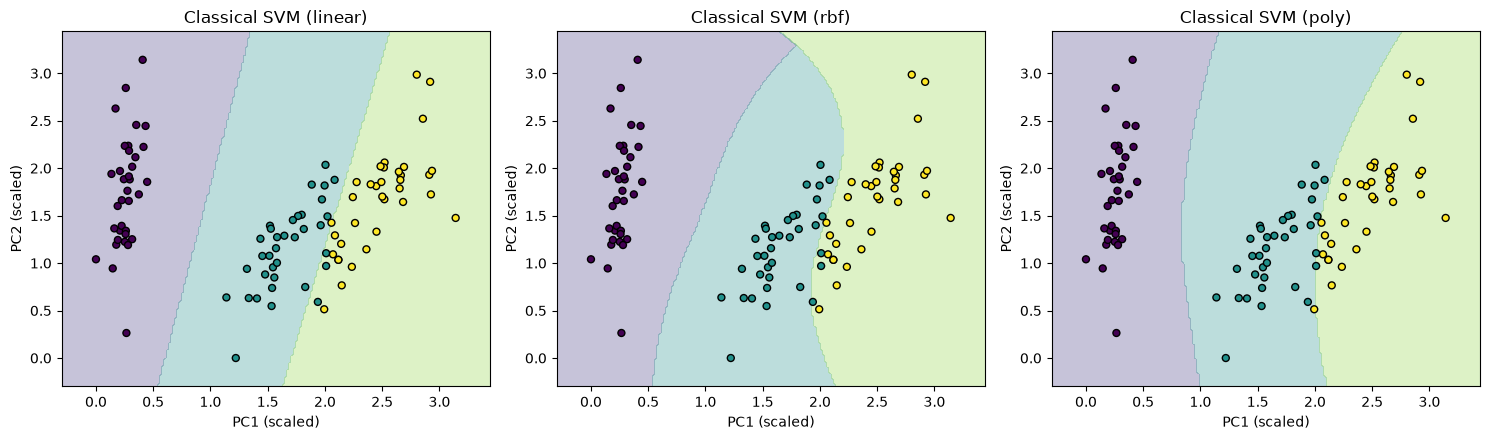

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RNG_SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pca_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_2d = pca_scaler.fit_transform(X_train_pca)
X_test_2d = pca_scaler.transform(X_test_pca)

pad = 0.3
x_min, x_max = X_train_2d[:, 0].min() - pad, X_train_2d[:, 0].max() + pad
y_min, y_max = X_train_2d[:, 1].min() - pad, X_train_2d[:, 1].max() + pad


def plot_decision_regions(ax, xx, yy, Z, X2d, y, title):
    ax.contourf(xx, yy, Z.reshape(xx.shape), alpha=0.3, cmap=plt.cm.viridis, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.scatter(X2d[:, 0], X2d[:, 1], c=y, cmap=plt.cm.viridis, edgecolor="k", s=25)
    ax.set_title(title)
    ax.set_xlabel("PC1 (scaled)")
    ax.set_ylabel("PC2 (scaled)")


grid_res_classical = 200
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_res_classical),
    np.linspace(y_min, y_max, grid_res_classical),
)
grid_2d = np.column_stack([xx.ravel(), yy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, kernel_name in zip(axes, ["linear", "rbf", "poly"]):
    svc_2d = SVC(kernel=kernel_name).fit(X_train_2d, y_train)
    Z = svc_2d.predict(grid_2d)
    plot_decision_regions(ax, xx, yy, Z, X_train_2d, y_train, f"Classical SVM ({kernel_name})")

plt.tight_layout()
plt.show()

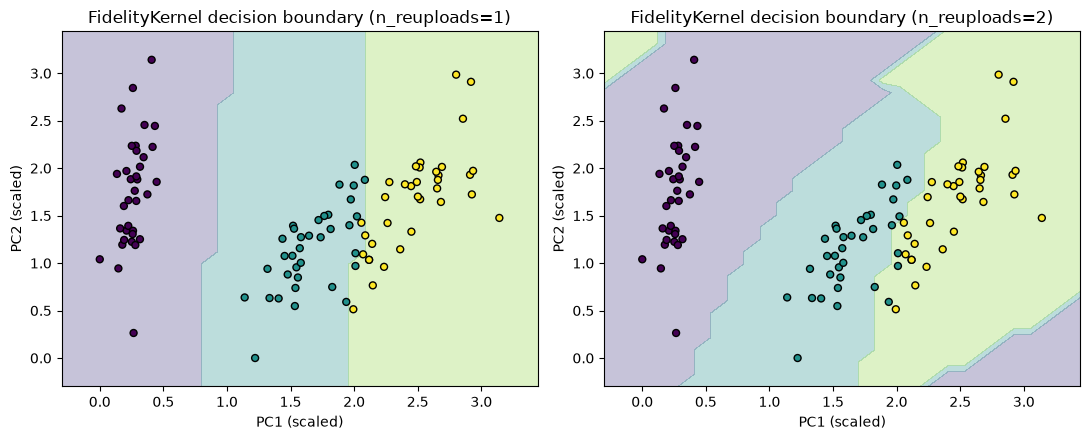

In [28]:
# Lower grid resolution than the classical plot: each grid point requires a full SLOS simulation.
grid_res_quantum = 30
xx_q, yy_q = np.meshgrid(
    np.linspace(x_min, x_max, grid_res_quantum),
    np.linspace(y_min, y_max, grid_res_quantum),
)
grid_2d_q_t = torch.tensor(np.column_stack([xx_q.ravel(), yy_q.ravel()]), dtype=torch.float32)
X_train_2d_t = torch.tensor(X_train_2d, dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, n_reuploads in zip(axes, [1, 2]):
    feature_map_2d, n_modes_2d = build_feature_map(n_features=2, n_reuploads=n_reuploads)
    kernel_2d = make_fidelity_kernel(feature_map_2d, n_modes_2d)

    train_input = tile_for_reupload(X_train_2d_t, 2, feature_map_2d.input_size)
    grid_input = tile_for_reupload(grid_2d_q_t, 2, feature_map_2d.input_size)

    K_train_2d = kernel_2d(train_input).detach().numpy()
    K_grid_2d = kernel_2d(grid_input, train_input).detach().numpy()

    svc_q = SVC(kernel="precomputed").fit(K_train_2d, y_train)
    Z_q = svc_q.predict(K_grid_2d)

    plot_decision_regions(
        ax, xx_q, yy_q, Z_q, X_train_2d, y_train,
        f"FidelityKernel decision boundary (n_reuploads={n_reuploads})",
    )

plt.tight_layout()
plt.show()